# POSet / ε-Dominance Engine

This notebook builds a reusable POSet pipeline for comparing countries across multiple structural variables.

The pipeline generates:

- Dominance matrix
- Comparability matrix
- Pareto frontier countries
- Country-level dominance summary
- Hasse edges
- POSet layers
- Epsilon sensitivity table
- Basic Hasse diagram visualization

Input requirement:

Each row should represent one country for one analysis year, with all ordering variables already cleaned, directionally aligned, and preferably normalized.

All ordering variables must follow:

> Higher value = structurally preferable condition

## Methodological note

A country A ε-dominates country B if:

1. A is not worse than B across all selected structural variables, allowing for a tolerance ε.
2. A is strictly better than B in at least one variable by more than ε.

Formally:

A dominates B if:

- Aᵢ ≥ Bᵢ − εᵢ for all variables i
- Aⱼ > Bⱼ + εⱼ for at least one variable j

where:

εᵢ = epsilon_k × standard deviation of variable i

The epsilon value is tested through sensitivity analysis. It should be selected based on POSet stability, comparability, frontier size, and interpretability — not based on which epsilon gives the best shock-validation result.

In [16]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [17]:
# ------------------------------------------------------
# Configuration
# ------------------------------------------------------

input_file = "dummy_poset_data.csv"

country_col = "country"

# Set this to the actual year column name in the real dataset.
# Examples: "year", "TIME_PERIOD", "Year"
year_col = None

# Set this only when the dataset has a year column.
# Example: analysis_year = 2019
analysis_year = None

selected_epsilon = 0.10

epsilon_grid = [0, 0.05, 0.10, 0.20, 0.30, 0.50, 0.75, 1.00]

In [18]:
# ------------------------------------------------------
# Load input data
# ------------------------------------------------------

df_raw = pd.read_csv(input_file)

df_raw.head()

,country,education,trust,innovation,debt_inverted,energy_security
0,Italy,0.60,0.45,0.50,0.40,0.35
1,Germany,0.75,0.70,0.80,0.65,0.55
2,France,0.70,0.60,0.65,0.50,0.45
3,Norway,0.80,0.85,0.75,0.80,0.90
4,Spain,0.65,0.50,0.45,0.45,0.40


In [19]:
# ------------------------------------------------------
# Filter to selected analysis year, if year column is present
# ------------------------------------------------------

if year_col is not None:
    if year_col not in df_raw.columns:
        raise ValueError(f"Year column '{year_col}' not found in dataset.")

    if analysis_year is None:
        raise ValueError("year_col is provided, but analysis_year is None. Please specify one analysis year.")

    df = df_raw[df_raw[year_col] == analysis_year].copy()

    if df.empty:
        raise ValueError(f"No rows found for analysis_year = {analysis_year}")

    print(f"Filtered dataset to {year_col} = {analysis_year}")
    print(f"Rows after filtering: {len(df)}")

else:
    df = df_raw.copy()
    print("No year column specified. Running POSet on full dataset.")

df.head()

No year column specified. Running POSet on full dataset.


,country,education,trust,innovation,debt_inverted,energy_security
0,Italy,0.60,0.45,0.50,0.40,0.35
1,Germany,0.75,0.70,0.80,0.65,0.55
2,France,0.70,0.60,0.65,0.50,0.45
3,Norway,0.80,0.85,0.75,0.80,0.90
4,Spain,0.65,0.50,0.45,0.45,0.40


In [20]:
# ------------------------------------------------------
# Basic input checks
# ------------------------------------------------------

if country_col not in df.columns:
    raise ValueError(f"Missing required country column: {country_col}")

excluded_cols = [country_col]

if year_col is not None:
    excluded_cols.append(year_col)

variable_cols = [col for col in df.columns if col not in excluded_cols]

if len(variable_cols) == 0:
    raise ValueError("No ordering variables found.")

# Check duplicate country rows after year filtering
duplicate_countries = df[df[country_col].duplicated()][country_col].tolist()

if len(duplicate_countries) > 0:
    raise ValueError(
        f"Duplicate country rows found after filtering: {duplicate_countries}. "
        "Each country should appear only once for the selected POSet year."
    )

non_numeric_cols = [
    col for col in variable_cols
    if not pd.api.types.is_numeric_dtype(df[col])
]

if len(non_numeric_cols) > 0:
    raise ValueError(f"These ordering variables are not numeric: {non_numeric_cols}")

missing_values = df[variable_cols].isna().sum()

if missing_values.sum() > 0:
    print("Missing values found:")
    print(missing_values[missing_values > 0])
    raise ValueError("Please clean/impute missing values before running POSet.")

print("Input validation passed.")
print(f"Number of countries: {df[country_col].nunique()}")
print(f"Ordering variables: {variable_cols}")

if year_col is not None:
    print(f"Analysis year: {analysis_year}")

Input validation passed.
Number of countries: 6
Ordering variables: ['education', 'trust', 'innovation', 'debt_inverted', 'energy_security']


In [21]:
# ------------------------------------------------------
# Core POSet functions
# ------------------------------------------------------

def dominates(a, b, epsilons):
    """
    Returns True if country A epsilon-dominates country B.

    A dominates B if:
    1. A is not worse than B by more than epsilon in every variable.
    2. A is strictly better than B by more than epsilon in at least one variable.
    """

    not_worse_all = np.all(a >= b - epsilons)
    strictly_better_one = np.any(a > b + epsilons)

    return not_worse_all and strictly_better_one


def build_dominance_matrix(data, country_col, variable_cols, epsilon_k):
    """
    Builds the dominance matrix for a given epsilon multiplier.

    epsilon_i = epsilon_k * std(variable_i)
    """

    countries = data[country_col].tolist()
    values = data[variable_cols].values

    variable_std = data[variable_cols].std().values
    epsilons = epsilon_k * variable_std

    n = len(countries)
    dominance_matrix = np.zeros((n, n), dtype=int)

    for i in range(n):
        for j in range(n):
            if i != j:
                if dominates(values[i], values[j], epsilons):
                    dominance_matrix[i, j] = 1

    dominance_df = pd.DataFrame(
        dominance_matrix,
        index=countries,
        columns=countries
    )

    return dominance_df, epsilons


def build_comparability_matrix(dominance_df):
    """
    Two countries are comparable if one dominates the other.
    """

    dominance_values = dominance_df.values

    comparability_values = dominance_values + dominance_values.T
    comparability_values = (comparability_values > 0).astype(int)

    comparability_df = pd.DataFrame(
        comparability_values,
        index=dominance_df.index,
        columns=dominance_df.columns
    )

    return comparability_df


def get_pareto_frontier(dominance_df):
    """
    Pareto frontier = countries not dominated by any other country.

    In the dominance matrix:
    - rows = country dominating others
    - columns = country being dominated
    - column sum = number of countries dominating that country
    """

    dominated_by_count = dominance_df.sum(axis=0)

    pareto_countries = dominated_by_count[
        dominated_by_count == 0
    ].index.tolist()

    return pareto_countries


def get_hasse_edges(dominance_df):
    """
    Returns direct dominance relations only.

    If A dominates B directly, keep A -> B.
    If A dominates B only through another country C,
    remove A -> B from the Hasse edge list.
    """

    countries = dominance_df.index.tolist()
    dominance = dominance_df.values

    hasse_edges = []

    n = len(countries)

    for i in range(n):
        for j in range(n):
            if dominance[i, j] == 1:

                is_transitive = False

                for k in range(n):
                    if k != i and k != j:
                        if dominance[i, k] == 1 and dominance[k, j] == 1:
                            is_transitive = True
                            break

                if not is_transitive:
                    hasse_edges.append({
                        "from_country": countries[i],
                        "to_country": countries[j]
                    })

    return pd.DataFrame(hasse_edges)

In [22]:
# ------------------------------------------------------
# Full POSet pipeline
# ------------------------------------------------------

def run_poset_pipeline(data, country_col, variable_cols, epsilon_k=0.10):
    """
    Runs the full POSet pipeline for a given dataset and epsilon value.

    Outputs:
    - dominance matrix
    - comparability matrix
    - Pareto frontier
    - country summary
    - Hasse edges
    - POSet layers
    - variable-specific epsilons
    """

    dominance_df, epsilons = build_dominance_matrix(
        data=data,
        country_col=country_col,
        variable_cols=variable_cols,
        epsilon_k=epsilon_k
    )

    comparability_df = build_comparability_matrix(dominance_df)

    pareto_countries = get_pareto_frontier(dominance_df)

    country_summary = pd.DataFrame({
        "country": dominance_df.index,
        "dominates_count": dominance_df.sum(axis=1).values,
        "dominated_by_count": dominance_df.sum(axis=0).values
    })

    country_summary["is_pareto_frontier"] = (
        country_summary["dominated_by_count"] == 0
    )

    country_summary = country_summary.sort_values(
        by=["is_pareto_frontier", "dominates_count"],
        ascending=[False, False]
    )

    hasse_edges_df = get_hasse_edges(dominance_df)

    G = nx.DiGraph()

    for country in data[country_col]:
        G.add_node(country)

    for _, row in hasse_edges_df.iterrows():
        G.add_edge(row["from_country"], row["to_country"])

    layer_rows = []

    for layer_number, generation in enumerate(nx.topological_generations(G), start=1):
        for country in sorted(generation):
            layer_rows.append({
                "poset_layer": layer_number,
                "country": country
            })

    layers_df = pd.DataFrame(layer_rows)

    epsilon_table = pd.DataFrame({
        "variable": variable_cols,
        "epsilon": epsilons
    })

    return {
        "dominance_matrix": dominance_df,
        "comparability_matrix": comparability_df,
        "pareto_countries": pareto_countries,
        "country_summary": country_summary,
        "hasse_edges": hasse_edges_df,
        "layers": layers_df,
        "epsilon_table": epsilon_table
    }

In [23]:
# ------------------------------------------------------
# Epsilon sensitivity analysis
# ------------------------------------------------------

def run_epsilon_sensitivity(data, country_col, variable_cols, epsilon_grid):
    """
    Tests different epsilon values and summarizes how the POSet structure changes.
    """

    summary_rows = []

    n = len(data)
    possible_pairs = n * (n - 1)

    for epsilon_k in epsilon_grid:
        results_k = run_poset_pipeline(
            data=data,
            country_col=country_col,
            variable_cols=variable_cols,
            epsilon_k=epsilon_k
        )

        dominance_df_k = results_k["dominance_matrix"]
        comparability_df_k = results_k["comparability_matrix"]
        pareto_countries_k = results_k["pareto_countries"]

        dominance_relations = dominance_df_k.values.sum()
        comparability_relations = comparability_df_k.values.sum()

        comparability_ratio = comparability_relations / possible_pairs

        summary_rows.append({
            "epsilon_k": epsilon_k,
            "dominance_relations": dominance_relations,
            "comparability_ratio": round(comparability_ratio, 3),
            "num_pareto_countries": len(pareto_countries_k),
            "pareto_countries": ", ".join(pareto_countries_k)
        })

    return pd.DataFrame(summary_rows)

In [24]:
# ------------------------------------------------------
# Run POSet pipeline for selected epsilon
# ------------------------------------------------------

results = run_poset_pipeline(
    data=df,
    country_col=country_col,
    variable_cols=variable_cols,
    epsilon_k=selected_epsilon
)

print(f"POSet pipeline completed for epsilon_k = {selected_epsilon}")

POSet pipeline completed for epsilon_k = 0.1


In [25]:
results["country_summary"]

,country,dominates_count,dominated_by_count,is_pareto_frontier
1,Germany,4,0,True
3,Norway,4,0,True
2,France,2,2,False
0,Italy,0,3,False
4,Spain,0,3,False
5,Poland,0,2,False


In [26]:
results["layers"]

,poset_layer,country
0,1,Germany
1,1,Norway
2,2,France
3,2,Poland
4,3,Italy
5,3,Spain


In [27]:
results["hasse_edges"]

,from_country,to_country
0,Germany,France
1,Germany,Poland
2,France,Italy
3,France,Spain
4,Norway,France
5,Norway,Poland


In [28]:
epsilon_summary = run_epsilon_sensitivity(
    data=df,
    country_col=country_col,
    variable_cols=variable_cols,
    epsilon_grid=epsilon_grid
)

epsilon_summary

,epsilon_k,dominance_relations,comparability_ratio,num_pareto_countries,pareto_countries
0,0.00,10,0.667,2,"Germany, Norway"
1,0.05,10,0.667,2,"Germany, Norway"
2,0.10,10,0.667,2,"Germany, Norway"
3,0.20,10,0.667,2,"Germany, Norway"
4,0.30,10,0.667,2,"Germany, Norway"
5,0.50,12,0.800,1,Norway
6,0.75,13,0.867,1,Norway
7,1.00,13,0.867,1,Norway


In [31]:
epsilon_summary_diagnostics = epsilon_summary.copy()

epsilon_summary_diagnostics["change_in_dominance_relations"] = (
    epsilon_summary_diagnostics["dominance_relations"].diff()
)

epsilon_summary_diagnostics["change_in_comparability_ratio"] = (
    epsilon_summary_diagnostics["comparability_ratio"].diff()
)

epsilon_summary_diagnostics["change_in_pareto_count"] = (
    epsilon_summary_diagnostics["num_pareto_countries"].diff()
)

epsilon_summary_diagnostics

,epsilon_k,dominance_relations,comparability_ratio,num_pareto_countries,pareto_countries,change_in_dominance_relations,change_in_comparability_ratio,change_in_pareto_count
0,0.00,10,0.667,2,"Germany, Norway",NaN,NaN,NaN
1,0.05,10,0.667,2,"Germany, Norway",0.0,0.000,0.0
2,0.10,10,0.667,2,"Germany, Norway",0.0,0.000,0.0
3,0.20,10,0.667,2,"Germany, Norway",0.0,0.000,0.0
4,0.30,10,0.667,2,"Germany, Norway",0.0,0.000,0.0
5,0.50,12,0.800,1,Norway,2.0,0.133,-1.0
6,0.75,13,0.867,1,Norway,1.0,0.067,0.0
7,1.00,13,0.867,1,Norway,0.0,0.000,0.0


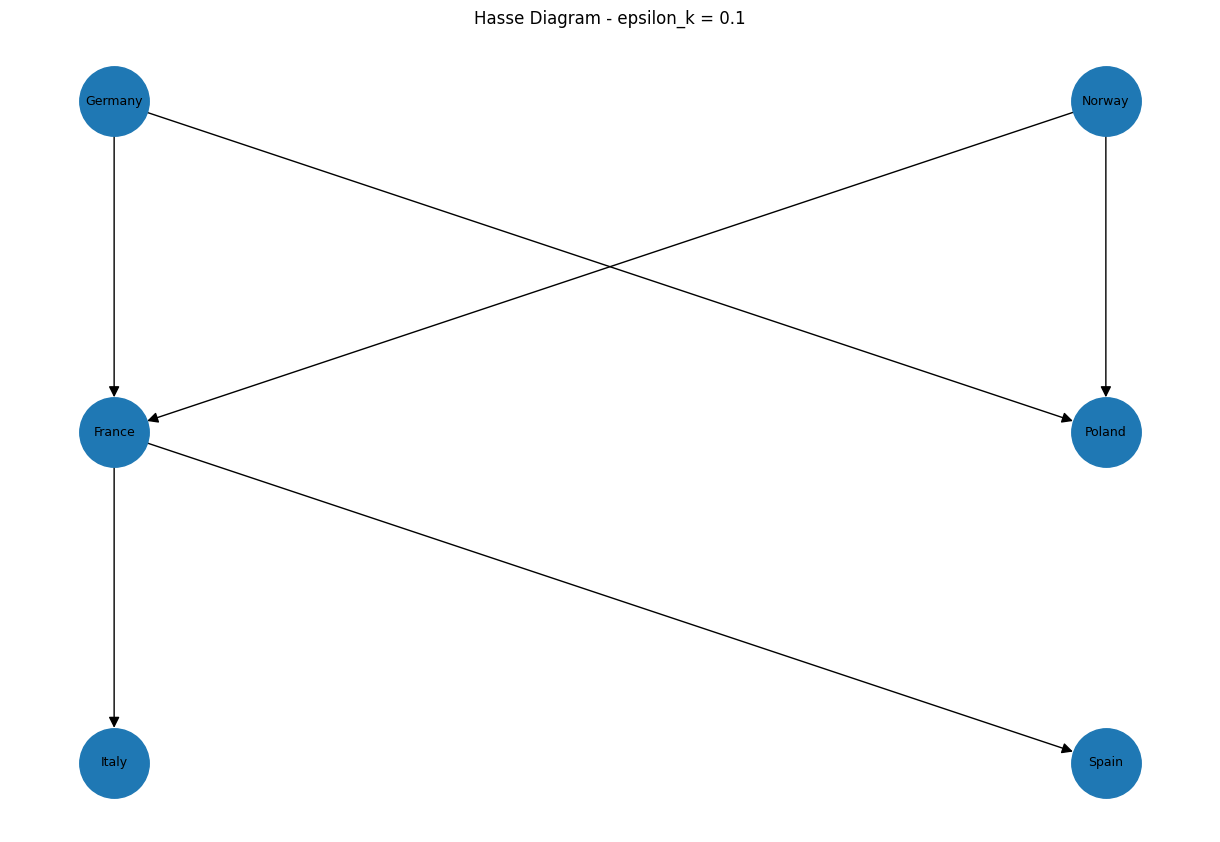

In [29]:
# ------------------------------------------------------
# Basic Hasse diagram visualization
# ------------------------------------------------------

def get_hierarchical_pos(G):
    """
    Creates a layered layout for a DAG/Hasse diagram.
    Top layer = nodes with no incoming edges.
    Lower layers = dominated nodes.
    """

    generations = list(nx.topological_generations(G))
    pos = {}

    for level, generation in enumerate(generations):
        generation = sorted(list(generation))
        width = len(generation)

        x_positions = np.linspace(
            -(width - 1) / 2,
            (width - 1) / 2,
            width
        )

        for x, node in zip(x_positions, generation):
            pos[node] = (x, -level)

    return pos


G = nx.DiGraph()

for country in df[country_col]:
    G.add_node(country)

for _, row in results["hasse_edges"].iterrows():
    G.add_edge(row["from_country"], row["to_country"])

plt.figure(figsize=(12, 8))

pos = get_hierarchical_pos(G)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2500,
    font_size=9,
    arrows=True,
    arrowsize=16
)

plt.title(f"Hasse Diagram - epsilon_k = {selected_epsilon}")
plt.axis("off")
plt.show()

In [30]:
# ------------------------------------------------------
# Export key outputs
# ------------------------------------------------------

epsilon_label = str(selected_epsilon).replace(".", "")

results["dominance_matrix"].to_csv(f"dominance_matrix_epsilon_{epsilon_label}.csv")
results["comparability_matrix"].to_csv(f"comparability_matrix_epsilon_{epsilon_label}.csv")
results["country_summary"].to_csv(f"country_summary_epsilon_{epsilon_label}.csv", index=False)
results["hasse_edges"].to_csv(f"hasse_edges_epsilon_{epsilon_label}.csv", index=False)
results["layers"].to_csv(f"poset_layers_epsilon_{epsilon_label}.csv", index=False)
results["epsilon_table"].to_csv(f"epsilon_table_epsilon_{epsilon_label}.csv", index=False)
epsilon_summary.to_csv("epsilon_sensitivity_summary.csv", index=False)

print("All POSet outputs exported successfully.")

All POSet outputs exported successfully.


## Interpretation guide

- Dominance matrix:
  - Row country dominates column country.
  - A value of 1 means the row country ε-dominates the column country.

- Comparability matrix:
  - A value of 1 means two countries are comparable because one dominates the other.
  - A value of 0 means the countries are incomparable.

- Pareto frontier:
  - Countries not dominated by any other country.
  - These should not be described as "best countries."
  - Better interpretation: countries with non-dominated structural profiles under the selected variables.

- Hasse edges:
  - Direct dominance relations after removing transitive/indirect dominance links.

- POSet layers:
  - Layer 1 contains non-dominated countries.
  - Lower layers contain countries increasingly dominated within the POSet structure.

- Epsilon sensitivity:
  - Used to examine whether the POSet structure is stable across different tolerance levels.
  - Epsilon should not be selected based on shock-validation outcomes.